In [1]:
# 노트북에서 상위 폴더의 모듈을 import하기 위한 경로 설정
import sys, os
sys.path.append(os.path.abspath(".."))   # notebooks/의 상위 = 프로젝트 루트

import torch
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())

torch: 2.6.0+cu124
cuda: True


In [2]:
from utils.data import get_dataloaders
from utils.train import fit
from utils.metrics import collect_predictions, print_metrics_report, get_confusion_matrix
from utils.visualize import (
    plot_learning_curve,
    plot_confusion_matrix,
    extract_features,
    plot_tsne,
)
from models.mlp import MLP

print("모든 모듈 import 성공")

모든 모듈 import 성공


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# 데이터 로딩 (train/val/test) — data_dir도 루트 기준으로
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=128,
    data_dir="../data"     # notebooks/의 상위 = 프로젝트 루트의 data/
)

# MLP 학습 (개발 단계니 15 epoch로 빠르게)
model = MLP()
history, best_epoch, test_result = fit(
    model, train_loader, val_loader, test_loader,
    epochs=15, device=device,
    save_path="../results/mlp_best.pth"   # 루트 기준
)

device: cuda
Epoch  1/15 | train_loss 0.2832 acc 0.9156 | val_loss 0.1502 acc 0.9545  <- best
Epoch  2/15 | train_loss 0.1079 acc 0.9673 | val_loss 0.1189 acc 0.9647  <- best
Epoch  3/15 | train_loss 0.0736 acc 0.9769 | val_loss 0.0899 acc 0.9732  <- best
Epoch  4/15 | train_loss 0.0527 acc 0.9834 | val_loss 0.0836 acc 0.9742  <- best
Epoch  5/15 | train_loss 0.0424 acc 0.9862 | val_loss 0.0935 acc 0.9723
Epoch  6/15 | train_loss 0.0321 acc 0.9897 | val_loss 0.0893 acc 0.9763
Epoch  7/15 | train_loss 0.0275 acc 0.9911 | val_loss 0.0994 acc 0.9718
Epoch  8/15 | train_loss 0.0254 acc 0.9914 | val_loss 0.0907 acc 0.9762
Epoch  9/15 | train_loss 0.0208 acc 0.9929 | val_loss 0.0902 acc 0.9765
Epoch 10/15 | train_loss 0.0176 acc 0.9940 | val_loss 0.1051 acc 0.9732
Epoch 11/15 | train_loss 0.0166 acc 0.9941 | val_loss 0.0974 acc 0.9763
Epoch 12/15 | train_loss 0.0144 acc 0.9949 | val_loss 0.1010 acc 0.9773
Epoch 13/15 | train_loss 0.0205 acc 0.9928 | val_loss 0.0897 acc 0.9778
Epoch 14/15 | t

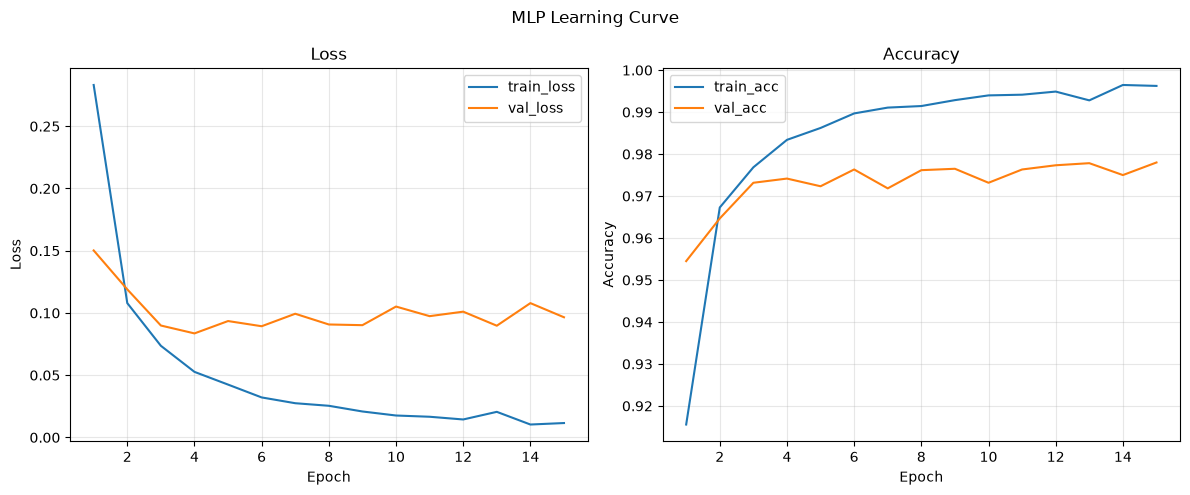

In [4]:
plot_learning_curve(history, title="MLP Learning Curve")

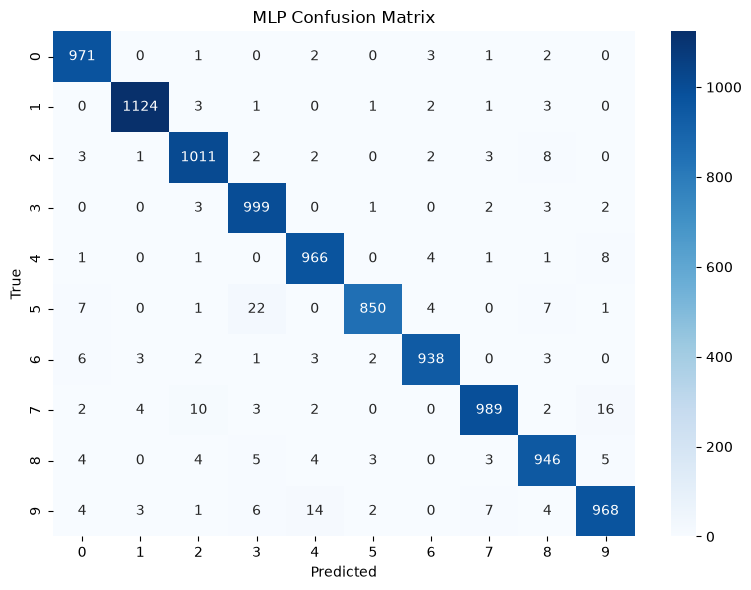

In [5]:
# best model로 test set 예측 수집
y_true, y_pred = collect_predictions(model, test_loader, device)

# confusion matrix heatmap (개수 버전)
plot_confusion_matrix(y_true, y_pred, title="MLP Confusion Matrix")

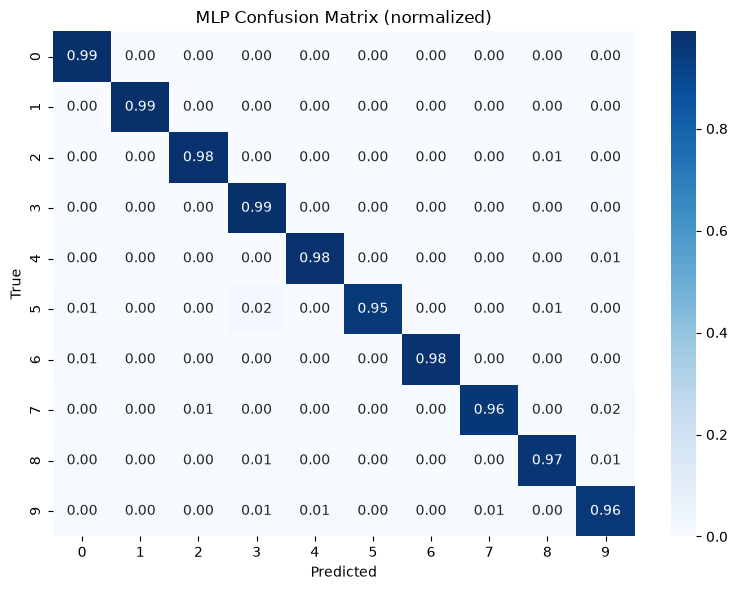

In [6]:
plot_confusion_matrix(y_true, y_pred, title="MLP Confusion Matrix (normalized)", normalize=True)

feature shape: (2000, 128)


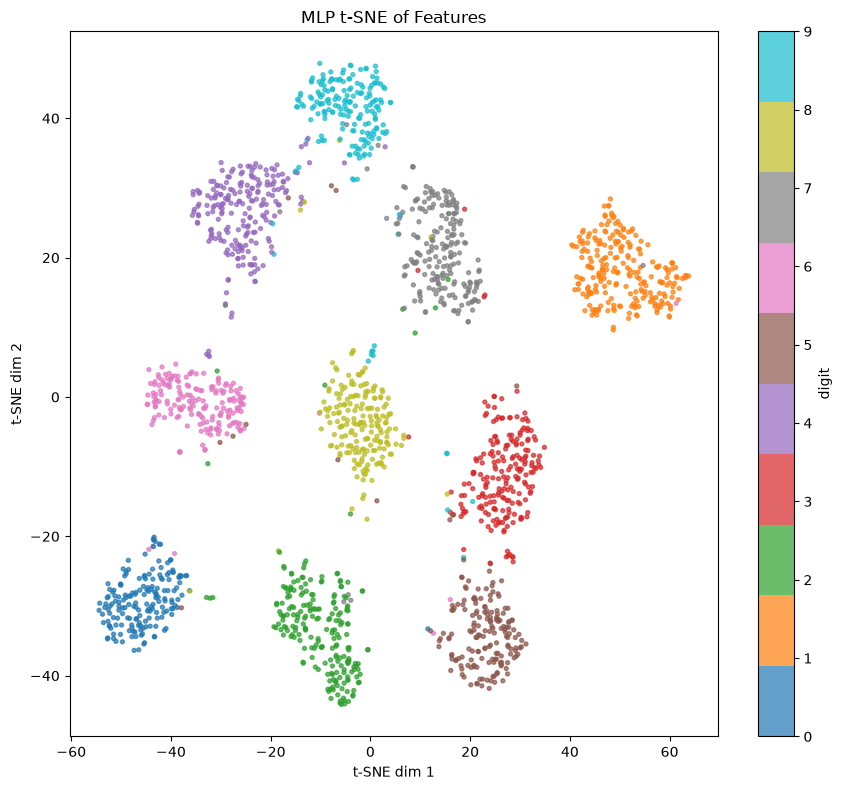

In [7]:
# penultimate feature 추출 (t-SNE는 느리니 2000개만)
features, labels = extract_features(model, test_loader, device, max_samples=2000)
print("feature shape:", features.shape)   # (2000, 128)

# t-SNE로 2D 투영해서 그리기
plot_tsne(features, labels, title="MLP t-SNE of Features")